In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append("..")  # Add parent directory to path for imports

In [4]:
import os
import dataclasses
import blockies
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
from blockies.plotvis import render_single_param

# SceneParameters: Description of a single image
The basic data type of the blockies module is *SceneParameters*. A SceneParameters object contains the attributes that describe a single 3D scene that can controlled and manipulated. We can create SceneParameters manually with the constructor which will be initialize with default values (see example below). In a later section we will demonstrate how to use samplers to sample these parameters in larger numbers.

In [5]:
base_param = blockies.SceneParameters()
base_param


SceneParameters(obj_name='healthy', num_ill_chars=0, ill_chars=(), labeling_error=False, main_spherical=0.9, sec_spherical=0.6, sec_bones='001', bending=0.0, obj_rotation_roll=0.0, obj_rotation_pitch=0.0, obj_rotation_yaw=0.0, fliplr=False, position_x=0.0, position_y=0.0, arm_position=0.0, obj_color=0.5, obj_color_rgba=(1.0, 0.9921568627450981, 0.9921568627450981, 1.0), bg_color=0.45, bg_color_rgba=(0.5490196078431373, 0.5490196078431373, 0.5490196078431373, 1.0), resolution=(256, 256), id='c7dbfe55-8ea8-4625-9a9a-d038a0aec7f8', original_id=None)

# Rendering SceneParameters
Now that we have a SceneParameter we want to create an image from these attributes. We simply need to pass it to the blender Module. The ``blender.render`` function is designed to receive a *list of SceneParameters* and return an enumerator to receive 
1. the rendered image
2. a segmentation mask
3. the parameters used to create the image (so that they can be saved to be used for later analysis).
All of these objects are returned by the enumerator once Blender finished rendering them.
Before we render our first image, please note that we have implemented doc strings that provide even more detail. 

In [6]:
blockies.blender.render?

Signature:
blockies.blender.render(
    params: Sequence[blockies.scene_parameters.SceneParameters],
    n_processes: int = 0,
    chunk_size: int = 100,
    output_dir: Optional[str] = None,
    blender_dir: Optional[str] = None,
    download_blender: bool = False,
    print_output: bool = False,
    print_cmd: bool = False,
    save_blender_file: bool = False,
) -> Iterator[Tuple[numpy.ndarray, numpy.ndarray, blockies.scene_parameters.SceneParameters]]
Docstring:
Renders the given parameters to images using Blender.

This function yields tuples of (image, mask, scene parameters). The order is
not preserved. Each block of the object is encoded as a unique integer value
in the mask. See ``SEGMENTATION_NAME_TO_INT``. For example, the left most
spine is encoded as ``3``.


Args:
    params: List of scence parameters.
    n_processes: Number of concurrent processes to run. The Default
        ``0`` means as many processes as cpus.
    chunk_size: Number of parameters to render per process

Here we will use the convenience function ``bender.render_single``, which returns a single image and segmentation mask for a single SceneParameter. We created this convenience function to inspect single images quickly. Please **DO NOT USE IT TO RENDER A SEQUENCE OF PARAMETERS** . Instead, use``blender.render`` which is more efficient. 
Please note: The download_blender flag will ensure Blender is installed.

In [7]:
base_param

SceneParameters(obj_name='healthy', num_ill_chars=0, ill_chars=(), labeling_error=False, main_spherical=0.9, sec_spherical=0.6, sec_bones='001', bending=0.0, obj_rotation_roll=0.0, obj_rotation_pitch=0.0, obj_rotation_yaw=0.0, fliplr=False, position_x=0.0, position_y=0.0, arm_position=0.0, obj_color=0.5, obj_color_rgba=(1.0, 0.9921568627450981, 0.9921568627450981, 1.0), bg_color=0.45, bg_color_rgba=(0.5490196078431373, 0.5490196078431373, 0.5490196078431373, 1.0), resolution=(256, 256), id='c7dbfe55-8ea8-4625-9a9a-d038a0aec7f8', original_id=None)

In [8]:
(img, mask) = blockies.blender.render_single(base_param, download_blender=True)

Ploting the image yields a peaky object:

(-0.5, 255.5, 255.5, -0.5)

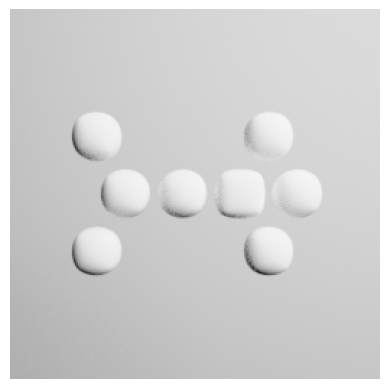

In [9]:
plt.imshow(img)
plt.axis('off')

In [10]:
base_param

SceneParameters(obj_name='healthy', num_ill_chars=0, ill_chars=(), labeling_error=False, main_spherical=0.9, sec_spherical=0.6, sec_bones='001', bending=0.0, obj_rotation_roll=0.0, obj_rotation_pitch=0.0, obj_rotation_yaw=0.0, fliplr=False, position_x=0.0, position_y=0.0, arm_position=0.0, obj_color=0.5, obj_color_rgba=(1.0, 0.9921568627450981, 0.9921568627450981, 1.0), bg_color=0.45, bg_color_rgba=(0.5490196078431373, 0.5490196078431373, 0.5490196078431373, 1.0), resolution=(256, 256), id='c7dbfe55-8ea8-4625-9a9a-d038a0aec7f8', original_id=None)

The renderer also returns an image mask which we visualize here:

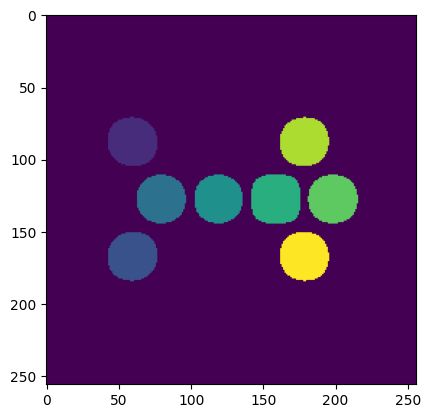

In [11]:
plt.imshow(mask)

In this example, we will render quite a few single images, so we will use another convenience function.

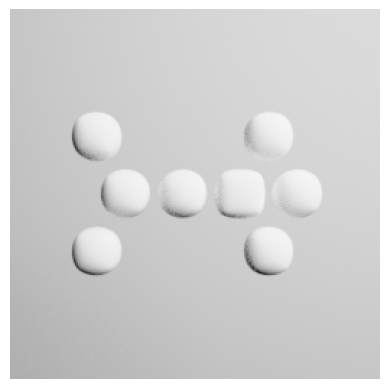

In [12]:
from blockies.plotvis import render_single_param
render_single_param(base_param);

The default SceneParameters always depict a peaky.
One can obtain the same set of default values with another convenience function:

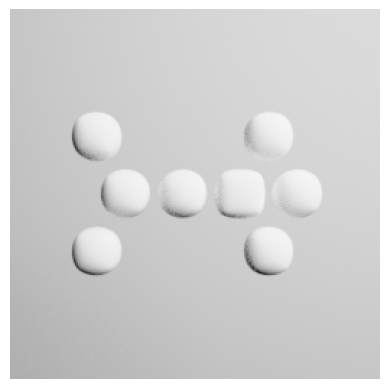

In [13]:
base_healthy = blockies.SceneParameters.default_healthy()
render_single_param(base_healthy);

In [14]:
base_healthy

SceneParameters(obj_name='healthy', num_ill_chars=0, ill_chars=(), labeling_error=False, main_spherical=0.9, sec_spherical=0.6, sec_bones='001', bending=0.0, obj_rotation_roll=0.0, obj_rotation_pitch=0.0, obj_rotation_yaw=0.0, fliplr=False, position_x=0.0, position_y=0.0, arm_position=0.0, obj_color=0.5, obj_color_rgba=(1.0, 0.9921568627450981, 0.9921568627450981, 1.0), bg_color=0.45, bg_color_rgba=(0.5490196078431373, 0.5490196078431373, 0.5490196078431373, 1.0), resolution=(256, 256), id='ec43b7c2-4c02-4601-a948-f02c89dd3a8a', original_id=None)

Similarly a convenience function exist to retrieve a stretchy:

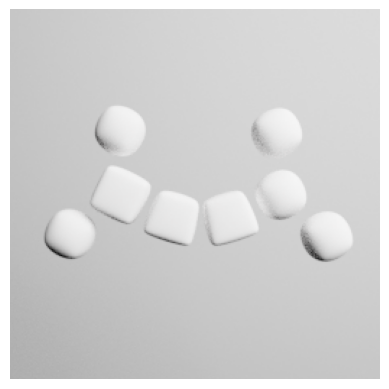

In [15]:
base_ocd = blockies.SceneParameters.default_ocd()
render_single_param(base_ocd);

In [16]:
base_ocd

SceneParameters(obj_name='ocd', num_ill_chars=3, ill_chars=['strong_bend', 'strong_sphere_diff', 'stretchy'], labeling_error=False, main_spherical=0.85, sec_spherical=0.3, sec_bones='111', bending=0.3, obj_rotation_roll=0.0, obj_rotation_pitch=0.0, obj_rotation_yaw=0.0, fliplr=False, position_x=0.0, position_y=0.0, arm_position=0.9, obj_color=0.5, obj_color_rgba=(1.0, 0.9921568627450981, 0.9921568627450981, 1.0), bg_color=0.45, bg_color_rgba=(0.5490196078431373, 0.5490196078431373, 0.5490196078431373, 1.0), resolution=(256, 256), id='8ed3f014-fcb5-4e2d-aa70-ee42f2b33dc5', original_id=None)

# Changing Attributes
The attributes of the SceneParameters can be changed manually.
For example, the attribute **fliplr** indicates if the object is flipped vertically (left/right)

In [18]:
fliped_healthy = blockies.SceneParameters()
fliped_healthy.fliplr

False

Since the parameters indicate the object is not flipped, we can change that by setting the attribute manually:

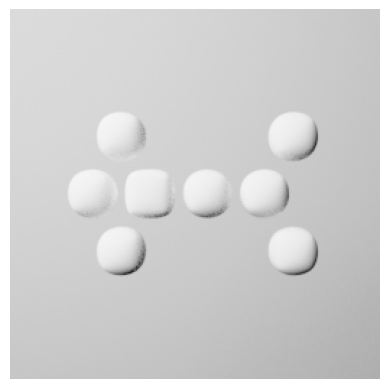

In [19]:
fliped_healthy.fliplr = True
render_single_param(fliped_healthy);

Next, let us look at the attribute of **roation**.
Here we are setting it to its minimum recommended value.

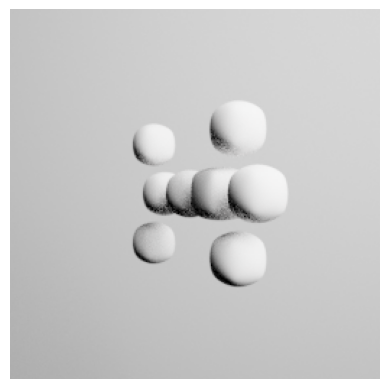

In [20]:
rotating_pitch_healthy = blockies.SceneParameters()
rotating_pitch_healthy.obj_rotation_pitch = blockies.SceneParameters.VALID_VALUES['obj_rotation_pitch'][0]
render_single_param(rotating_pitch_healthy);

After that, we are setting it to its recommended maximum value:

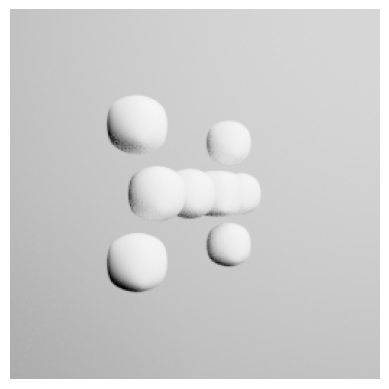

In [22]:
rotating_pitch_healthy.obj_rotation_pitch = blockies.SceneParameters.VALID_VALUES['obj_rotation_pitch'][1]
render_single_param(rotating_pitch_healthy);

It is possible to set attributes outside of the recommended values:

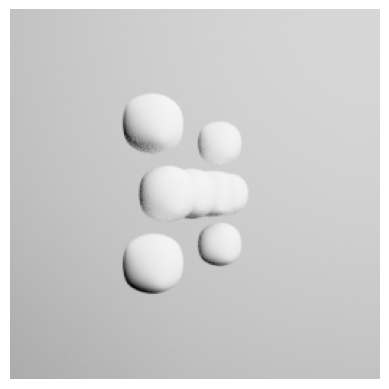

In [23]:
rotating_pitch_healthy.obj_rotation_pitch = 1.2
render_single_param(rotating_pitch_healthy);

To check whether values are with recommended ranges you can use *check_value*:

In [24]:
try:
  rotating_pitch_healthy.check_values()
except ValueError as e:
  print(e)

Attribute obj_rotation_pitch has value 1.2 but valid values would be in (-1.0471975511965976, 1.0471975511965976).


The following examples will illustrate the other attributes and their corresponding
maximum and minimum recommended values.
The following examples shows the **inclination**.

Please note: For roation_yaw are taking half of the max and min value since the yaw rotation has the range (-PI,+PI), which is a full rotation, resulting in the same image as the original.

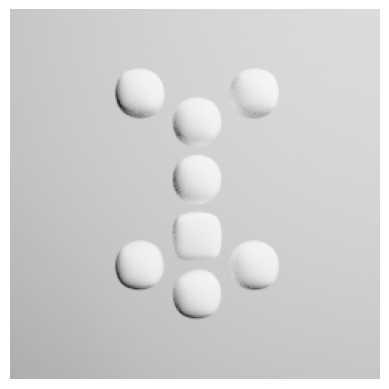

In [25]:
rotating_yaw_healthy = blockies.SceneParameters()
rotating_yaw_healthy.obj_rotation_yaw = 0.5*blockies.SceneParameters.VALID_VALUES['obj_rotation_yaw'][0]
render_single_param(rotating_yaw_healthy);

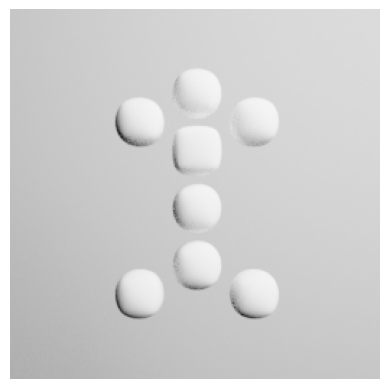

In [26]:
rotating_yaw_healthy.obj_rotation_yaw = 0.5*blockies.SceneParameters.VALID_VALUES['obj_rotation_yaw'][1]
render_single_param(rotating_yaw_healthy);

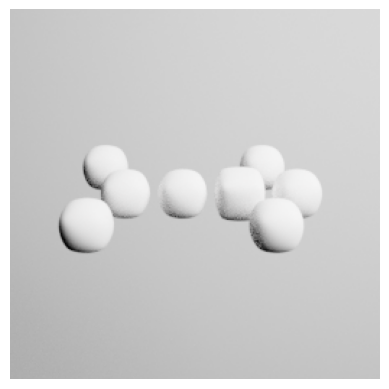

In [27]:
rotating_roll_healthy = blockies.SceneParameters()
rotating_roll_healthy.obj_rotation_roll = blockies.SceneParameters.VALID_VALUES['obj_rotation_roll'][0]
render_single_param(rotating_roll_healthy);

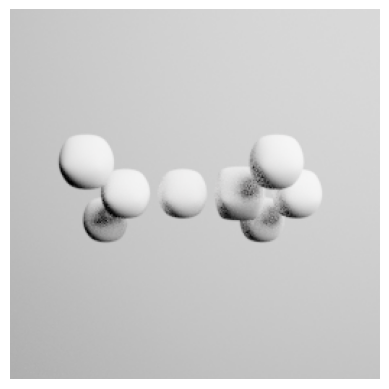

In [28]:
rotating_roll_healthy.obj_rotation_roll = blockies.SceneParameters.VALID_VALUES['obj_rotation_roll'][1]
render_single_param(rotating_roll_healthy);

We can also alter the **position** in the scene:

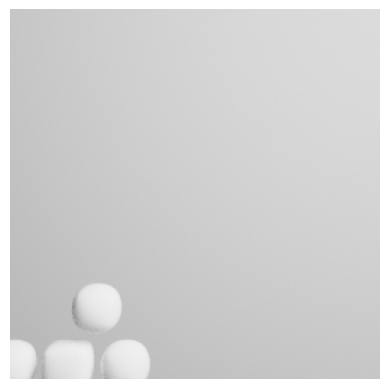

In [29]:
right_down_healthy = blockies.SceneParameters()
right_down_healthy.position_x = blockies.SceneParameters.VALID_VALUES['position_x'][0]
right_down_healthy.position_y = blockies.SceneParameters.VALID_VALUES['position_y'][0]
render_single_param(right_down_healthy);

The 8 building blocks of peaky and stretchy can be altered to be more or less **spherical**:

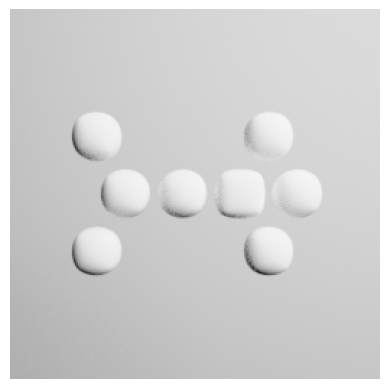

In [32]:
spherical_healthy = blockies.SceneParameters()
spherical_healthy.spherical = blockies.SceneParameters.VALID_VALUES['main_spherical'][1]
render_single_param(spherical_healthy);

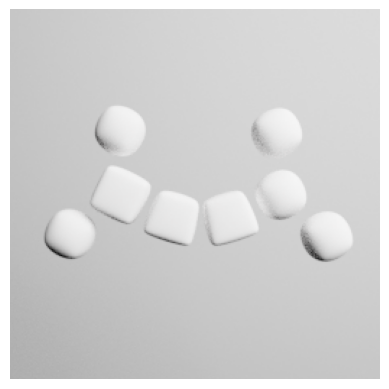

In [34]:
cubic_ocd = blockies.SceneParameters.default_ocd()
cubic_ocd.spherical = blockies.SceneParameters.VALID_VALUES['main_spherical'][0]
render_single_param(cubic_ocd);

The objects can take on "postures" with the attribute **bending**:

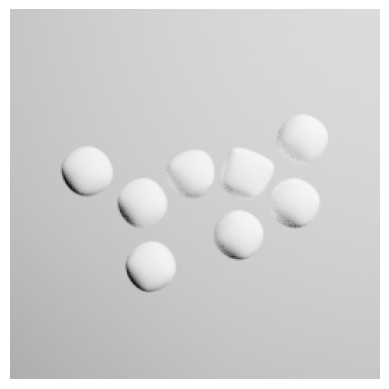

In [35]:
bending_healthy = blockies.SceneParameters()
bending_healthy.bending = blockies.SceneParameters.VALID_VALUES['bending'][0]
bending_healthy.check_values()
render_single_param(bending_healthy);


You can also manually set the RBGA values of the **object color** and the **background color**. However, we recommend using Samplers (which are introduced in the next section) to set the color. The example below illustrates how one can set RBA values:

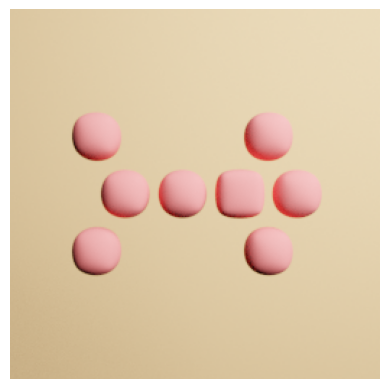

In [36]:
clr_healthy = blockies.SceneParameters()
clr_healthy.obj_color_rgba=(1.0, 0.1764705882352946, 0.1764705882352946, 1.0)
clr_healthy.bg_color_rgba=(0.9921568627450981, 0.5529411764705883, 0.23529411764705882, 1.0)
render_single_param(clr_healthy);

# Sampling large numbers of SceneParameters
In practice, we usually do not create SceneParameters manually. Instead, we use a sampler to sample these attributes from given distributions. The command below creates the default sample provided with this module:

In [37]:
sampler = blockies.BlockySampler()

Here we use the default provided sample to generate an example.
Try rerunning the cell and see how it changes:

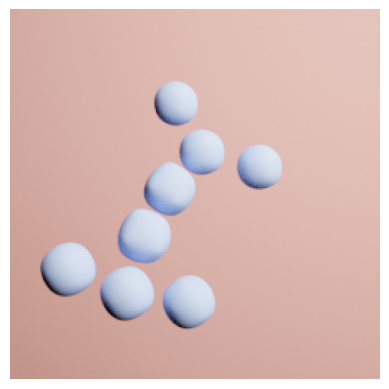

In [38]:
sampled_params = sampler.sample()
render_single_param(sampled_params);

We can create several examples using list comprehension, randomly creating several strechies and peakies. Also, there is a useful helper function that renders these examples in an image grid.

In [39]:
from blockies.plotvis import render_grid

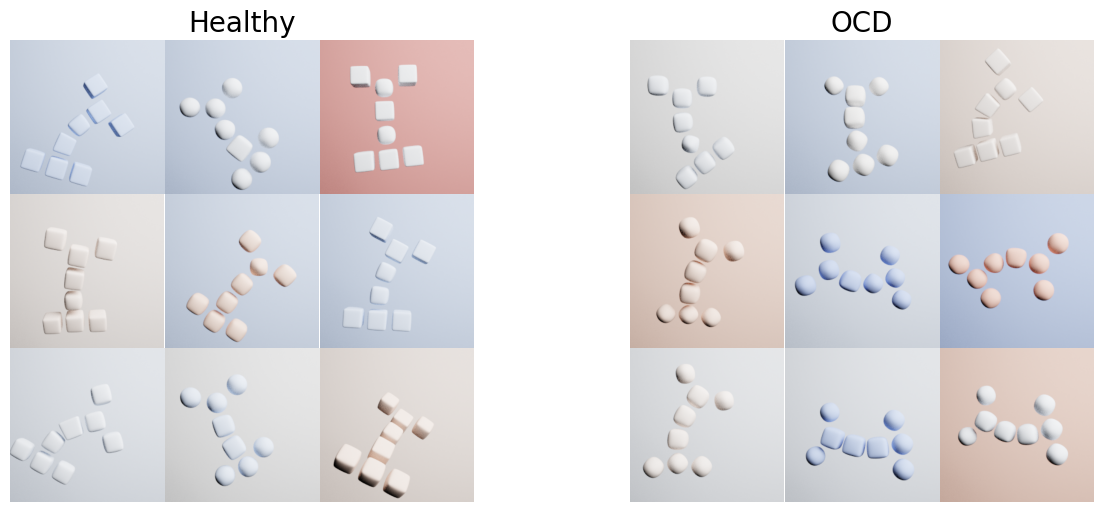

In [43]:
params = [sampler.sample() for i in range(18)]
render_grid(params, label_class_axis=True);

A sampler works by setting attributes using a distribution. Since it does not really produce aesthetically pleasing images when you are sampling rgba values from a distribution, we are sampling canonical values for the color that we then map to a matplotlib color map. This is the reason why SampleParameters stores two types of attributes for colors. In addition, the samplers keep track of the colormap that is used for setting the rgba values.

Background color: The sampled scalar color value of 0.0661067209726457 is in rgba value of (0.4196078431372549, 0.6823529411764706, 0.8392156862745098, 1.0) on the tab20c color map
Object color: The sampled scalar color value of 0.75934500571074 is in rgba value of (0.9784313725490196, 0.0, 0.0, 1.0) on the seismic color map


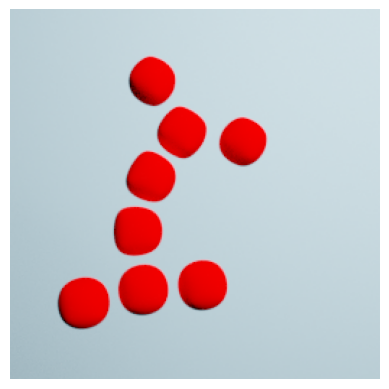

In [44]:
clr_sampler = blockies.BlockySampler()
clr_sampler.bg_color_map = 'tab20c'
clr_sampler.obj_color_map = 'seismic'
sampled_params = clr_sampler.sample()
print(f"Background color: The sampled scalar color value of {sampled_params.bg_color} is in rgba value of {sampled_params.bg_color_rgba} on the {clr_sampler.bg_color_map} color map" )
print(f"Object color: The sampled scalar color value of {sampled_params.obj_color} is in rgba value of {sampled_params.obj_color_rgba} on the {clr_sampler.obj_color_map} color map" )
render_single_param(sampled_params);

We can also use a sampler to sample individual attributes of SceneParameters.
This is useful to visualize how each attribute is sampled and understanding how one might change the distribution of the sampler to produce different data.
In the example that follows, we define 18 default strechies and 18 default peakies to then only sampler their **color**. We then sort them by their color and visualize them in a grid. The first columns are filled with Peakies, and the last 3 columns with strechies.

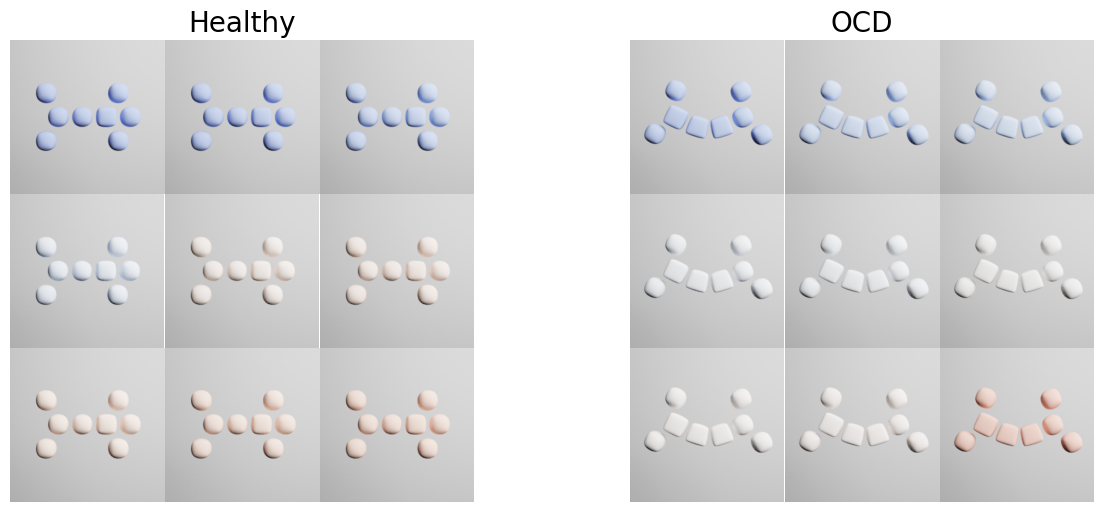

In [45]:
num_images = 18
healthy = [blockies.SceneParameters.default_healthy() for i in range(int(num_images/2))]
ocd = [blockies.SceneParameters.default_ocd() for i in range(int(num_images/2))]

_ = [sampler.sample_obj_color(params) for params in healthy + ocd]
ocd.sort(key=lambda x: x.obj_color)
healthy.sort(key=lambda x: x.obj_color)
render_grid(healthy + ocd);